# Stiftung Tierärztliche Hochschule Hannover - Mapping

In [5]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [7]:
client = bigquery.Client(project='subugoe-collaborative')

In [8]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Stiftung Tierärztliche Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/015qjqf64' -- 'Stiftung Tierärztliche Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [9]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Institute for Animal Nutrition, University of ...",https://openalex.org/W4294278577
1,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Clinic for Swine and Small Ruminants, Forensic...",https://openalex.org/W4294278577
2,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Department of Biometry, Epidemiology and Infor...",https://openalex.org/W4308124574
3,not assigned,Stiftung Tierärztliche Hochschule Hannover,Research Center for Emerging Infections and Zo...,https://openalex.org/W4308124574
4,not assigned,Stiftung Tierärztliche Hochschule Hannover,"Institute for Parasitology, Center for Infecti...",https://openalex.org/W4308124574


In [58]:
MAPPING_DICT = {
    'Anatomisches Institut': ['anatomy'],
    #'Arbeitsgruppe Vektor-assoziierte Biodiversität und Infektionen': [],
    'Fachgebiet Allgemeine Radiologie und Medizinische Physik': ['general radiology', 'department of radiology'],
    'Gesellschaft für Innovative Veterinärdiagnostik (IVD GmbH)': ['innovative veterinary diagnostics', 'innovative veterinärdiagnostik', 'ivd gmbh'],
    'Hochschulbibliothek': ['bibliothek', 'library'],
    'Institut für Biochemie': ['bio(chemi(e|stry))'],
    'Institut für Biometrie, Epidemiologie und Informationsverarbeitung': ['biometr(ie|y)'],
    'Institut für Immunologie': ['immunolog(ie|y)'],
    'Institut für Lebensmittelqualität und -sicherheit': ['food quality', 'food safety', 'lebensmittelqualität'],
    'Institut für Lebensmitteltoxikologie und Chemische Analytik': ['food toxicology'],
    'Institut für Mikrobiologie': ['mi(k|c)robiolog(ie|y)'],
    'Institut für Parasitologie': ['parasitolog(ie|y)', 'fish disease'],
    'Institut für Pathologie': ['patholog(ie|y)'],
    'Institut für Pharmakologie, Toxikologie und Pharmazie': ['neurowissenschaften', 'neuroscience', 'pharma(k|c)olog(ie|y)'],
    'Institut für Physiologie und Zellbiologie': ['physiologi(sche|cal) chemi(e|stry)', 'physiolog(ie|y|ical)', 'zellbiologie'],
    'Institut für Reproduktionsbiologie': ['reproductive biology', 'reproduktionsbiologie'],
    'Institut für Terrestrische und Aquatische Wildtierforschung': ['wildtierforschung', 'terrestrial'],
    'Institut für Tierernährung': ['animal nutrition', 'tierernährung'],
    'Institut für Tiergenomik': ['animal genomics'],
    'Institut für Tierhygiene, Tierschutz und Nutztierethologie': ['tierhygiene', 'animal hygiene', 'farm animal'],
    'Institut für Tierzucht und Vererbungsforschung': ['animal breeding', 'tierzucht'],
    'Institut für Tierökologie': ['animal ecology', 'ecology and evolution', 'tierökologie'],
    'Institut für Virologie': ['virolog(ie|y)'],
    'Institut für Zoologie': ['zoolog(ie|y)', 'zoologisches institut'],
    'Klinik für Geflügel': ['poultry', 'geflügel'],
    'Klinik für Heimtiere, Reptilien, Zier- und Wildvögel': ['reptil(ien|e)'],
    'Klinik für kleine Klauentiere und Forensische Medizin und Ambulatorische Klinik': ['klauentiere', 'forensic', 'clinic for swine'],
    'Klinik für Kleintiere': ['small animal', 'kleintiere', 'neurologie', 'small domestic animals', 'kleintierklinik'],
    'Klinik für Pferde': ['clinic for horses', 'klinik f(ü)?r pferde', 'equine clinic'],
    'Klinik für Rinder': ['clinic for cattle', 'klinik für rinder', 'diseases of cattle', 'cattle clinic'],
    'Lehr- und Forschungsgut Ruthe': ['farm for education( and research ruthe)?', 'forschungsgut ruthe'], #selbst egänzt
    'Reproduktionsmedizinische Einheit der Kliniken': ['biostabilization laboratory', 'reproductive medicine', 'reproduktionsmedizinische'],
    'Research Center for Emerging Infections and Zoonoses (RIZ)': ['zoonos(e|i)s', 'infection genetics'],
    'Zentrum für E-Learning, Didaktik und Ausbildungsforschung': ['e(-|‐)learning', 'clinical skills lab', 'cent(re|er) for teaching'], #selbst ergänzt
    'Außenstelle für Epidemiologie': ['epidemiolog(ie|y)'],
}

In [59]:
with open('./mapping_tables_fak/tiho.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [60]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [61]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [62]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Institut für Tierernährung,Stiftung Tierärztliche Hochschule Hannover,"Institute for Animal Nutrition, University of ...",https://openalex.org/W4294278577
1,Klinik für kleine Klauentiere und Forensische ...,Stiftung Tierärztliche Hochschule Hannover,"Clinic for Swine and Small Ruminants, Forensic...",https://openalex.org/W4294278577
2,"Institut für Biometrie, Epidemiologie und Info...",Stiftung Tierärztliche Hochschule Hannover,"Department of Biometry, Epidemiology and Infor...",https://openalex.org/W4308124574
3,Research Center for Emerging Infections and Zo...,Stiftung Tierärztliche Hochschule Hannover,Research Center for Emerging Infections and Zo...,https://openalex.org/W4308124574
4,Institut für Parasitologie,Stiftung Tierärztliche Hochschule Hannover,"Institute for Parasitology, Center for Infecti...",https://openalex.org/W4308124574
...,...,...,...,...
6085,Institut für Terrestrische und Aquatische Wild...,Stiftung Tierärztliche Hochschule Hannover,Institute for Terrestrial and Aquatic Wildlife...,https://openalex.org/W3014205161
6086,Institut für Pathologie,Stiftung Tierärztliche Hochschule Hannover,"Department of Pathology, University of Veterin...",https://openalex.org/W3047294470
6087,Institut für Pathologie,Stiftung Tierärztliche Hochschule Hannover,"Department of Pathology, University of Veterin...",https://openalex.org/W3047294470
6088,Außenstelle für Epidemiologie,Stiftung Tierärztliche Hochschule Hannover,"Field Station for Epidemiology, University of ...",https://openalex.org/W3128397251


In [63]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['University of Veterinary Medicine Hannover Hannover',
       'University of Veterinary Medicine Hannover, Hannover',
       'University of Veterinary Medicine Hannover Foundation, Hannover, Germany',
       '2Stiftung Tierärztliche Hochschule, University, Hannover, Germany',
       'University of Veterinary Medicine, Hannover, Germany',
       'University of Veterinary Medicine, Hannover, Germany,',
       'DFG-Graduiertenkolleg „Virusdetektion, Pathogenese und\n                    Intervention“ (VIPER - 398066876/GRK 2485/1), Stiftung\n                    Tierärztliche Hochschule Hannover',
       'Stiftung Tierärztliche Hochschule Hannover, Hannover, Germany',
       'University of Veterinary Medicine Hannover, Foundation',
       'University of Veterinary Medicine Hannover, Hannover, Germany',
       'University of Veterinary Medicine [Hannover] (Bünteweg 9, 30559 Hannover, Allemagne - Germany)',
       'Global Virus Network, Center of Excellence, University of Veterinary Me

In [64]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Anatomisches Institut,81
1,Außenstelle für Epidemiologie,90
2,Fachgebiet Allgemeine Radiologie und Medizinis...,16
3,Gesellschaft für Innovative Veterinärdiagnosti...,16
4,Hochschulbibliothek,2
5,Institut für Biochemie,206
6,"Institut für Biometrie, Epidemiologie und Info...",250
7,Institut für Immunologie,110
8,Institut für Lebensmittelqualität und -sicherheit,252
9,Institut für Lebensmitteltoxikologie und Chemi...,12


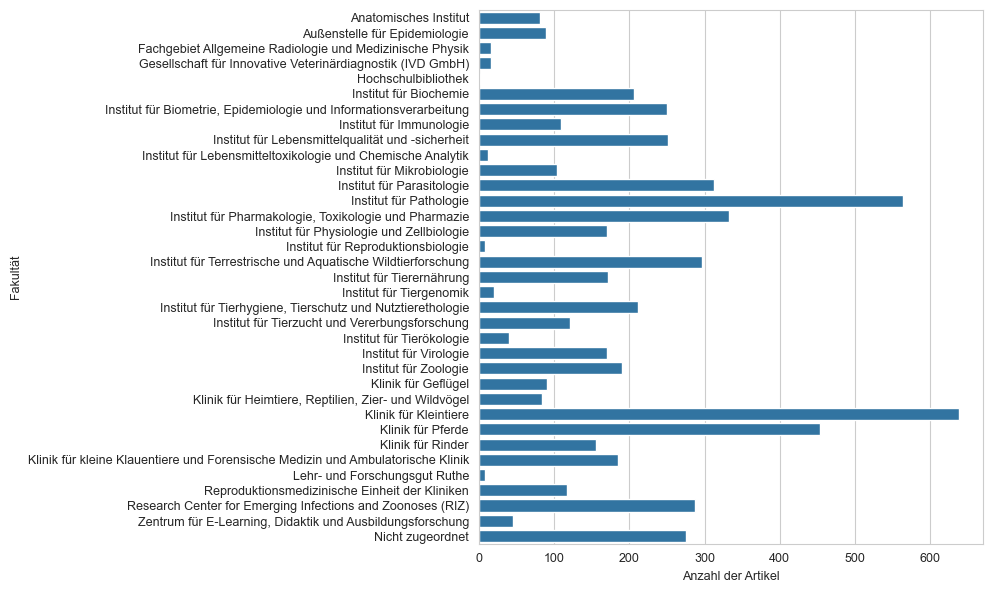

In [65]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [66]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.9548440065681445

In [67]:
MAPPING_DICT_DEPT = {}
MAPPING_DICT_INST = {}

In [68]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Stiftung Tierärztliche Hochschule Hannover'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/tiho.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)